# Ambiguity Aversion × Gaze Coupling

**Two-part mechanistic analysis**:

### Part A — Cross-sectional (N≈80 subjects)
Do subjects with *higher ambiguity aversion* also show *stronger oculomotor coupling*
to ambiguity? Aversion = behavioural avoidance of uncertain options;
gaze coupling = how strongly each subject's eye movements respond to ambiguity.

If correlated → gaze is an oculomotor expression of aversion (hesitation/vigilance).
If anti-correlated or dissociated → gaze reflects information-*seeking* independent of aversion.

### Part B — Visit Trajectory (N=19 matched V1/V2 pairs)
Does the V1→V2 *decrease in aversion* (from notebook 13) co-occur with a
*decrease in gaze coupling*? If yes: learning decouples the eyes from ambiguity
as a unified habituation process.

In [2]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.special import logit
import statsmodels.formula.api as smf
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)

OUT = Path('../../data/results/main/aversion_gaze_coupling')
OUT.mkdir(parents=True, exist_ok=True)


## 1. Load Data

In [3]:
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)
merged_df   = feature_data['merged_df'].copy()
gaze_cols   = feature_data['gaze_cols']

# Restrict to 80-subject EEG set (same as notebook 13)
EEG_ACC_PATH = '../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv'
eeg_subjects = set(pd.read_csv(EEG_ACC_PATH)['subject_id'])
df = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()

# Add visit info
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']
df = df.merge(sm[['subject_id', 'visit_number', 'team', 'user_id']], on='subject_id', how='left')

print(f"Dataset: {len(df)} trials, {df['subject_id'].nunique()} subjects")
print(f"Gaze features ({len(gaze_cols)}): {gaze_cols}")


Dataset: 9618 trials, 80 subjects
Gaze features (20): ['gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max', 'gaze_acceleration_mean', 'gaze_acceleration_std', 'fixation_ratio', 'saccade_ratio', 'saccade_count', 'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length']


## 2. Compute Per-Subject Scores

**Ambiguity aversion score** (from notebook 13):
```
aversion = invest_rate(ambiguity=0) − invest_rate(ambiguity>0)
```

**Gaze coupling score**: per-subject fixed-effect slope of
`gaze_feature ~ ambiguity` (OLS within subject, then aggregate).
We use the three most significant features from notebook 11b:
`gaze_y_std`, `gaze_y_mean`, `gaze_x_std`.
The coupling score is the mean |β| across these three features,
signed by whether ambiguity increases or decreases the feature.

In [4]:
# Gaze features most strongly driven by ambiguity (from notebook 11b)
COUPLING_FEATURES = ['gaze_y_std', 'gaze_y_mean', 'gaze_x_std']

def subject_scores(trials):
    """Return aversion score and per-feature gaze coupling betas for one subject."""
    if len(trials) < 20:
        return None

    # Ambiguity aversion
    r0   = trials[trials['ambiguity'] == 0]['outcome'].mean()
    rpos = trials[trials['ambiguity'] >  0]['outcome'].mean()
    if pd.isna(r0) or pd.isna(rpos):
        return None
    aversion = r0 - rpos

    # Gaze coupling: OLS beta of each feature ~ ambiguity (within subject, no controls)
    amb = trials['ambiguity'].values
    amb_z = (amb - amb.mean()) / (amb.std() + 1e-9)
    coupling_betas = {}
    for col in COUPLING_FEATURES:
        if col not in trials.columns:
            continue
        feat = trials[col].dropna()
        common_idx = feat.index.intersection(trials.index)
        if len(common_idx) < 10:
            continue
        f_vals = trials.loc[common_idx, col].values
        a_vals = amb_z[trials.index.get_indexer(common_idx)]
        if a_vals.std() == 0:
            continue
        beta = np.cov(f_vals, a_vals)[0, 1] / np.var(a_vals)
        coupling_betas[col] = beta

    if not coupling_betas:
        return None

    # Summary coupling score: mean |beta| (unsigned magnitude of gaze-ambiguity coupling)
    coupling_score = np.mean(np.abs(list(coupling_betas.values())))

    return {
        'aversion': aversion,
        'coupling_score': coupling_score,
        **{f'beta_{k}': v for k, v in coupling_betas.items()}
    }


rows = []
for subj, grp in df.groupby('subject_id'):
    res = subject_scores(grp)
    if res is None:
        continue
    meta = grp[['visit_number', 'team', 'user_id']].iloc[0]
    rows.append({'subject_id': subj,
                 'visit_number': meta['visit_number'],
                 'team': meta['team'],
                 'user_id': meta['user_id'],
                 **res})

subj_df = pd.DataFrame(rows)
print(f"Subject-level scores: {len(subj_df)} rows")
print(subj_df[['aversion', 'coupling_score'] + [f'beta_{c}' for c in COUPLING_FEATURES]].describe().round(3))


Subject-level scores: 80 rows
       aversion  coupling_score  beta_gaze_y_std  beta_gaze_y_mean  \
count    80.000          80.000           80.000            80.000   
mean      0.238           0.006           -0.003             0.007   
std       0.234           0.003            0.003             0.006   
min      -0.493           0.000           -0.014            -0.003   
25%       0.053           0.004           -0.005             0.003   
50%       0.234           0.006           -0.003             0.007   
75%       0.403           0.007           -0.002             0.010   
max       0.839           0.013            0.005             0.029   

       beta_gaze_x_std  
count           80.000  
mean             0.005  
std              0.007  
min             -0.011  
25%              0.001  
50%              0.004  
75%              0.009  
max              0.022  


## 3. Part A — Cross-Sectional Correlation

Simple OLS and Spearman correlation: `coupling_score ~ aversion_score`.

In [5]:
clean = subj_df[['subject_id', 'visit_number', 'aversion', 'coupling_score',
                  'team', 'user_id'] +
                [f'beta_{c}' for c in COUPLING_FEATURES]].dropna()

print(f"N for cross-sectional analysis: {len(clean)}")

# Spearman correlation (robust, no normality assumption)
r_sp, p_sp = stats.spearmanr(clean['aversion'], clean['coupling_score'])
# Pearson
r_pe, p_pe = stats.pearsonr(clean['aversion'], clean['coupling_score'])

print(f"\nAversion × Gaze Coupling:")
print(f"  Spearman r = {r_sp:.3f},  p = {p_sp:.3e}")
print(f"  Pearson  r = {r_pe:.3f},  p = {p_pe:.3e}")

# OLS with visit as covariate
ols = smf.ols('coupling_score ~ aversion + C(visit_number)', data=clean).fit()
print(f"\nOLS (coupling ~ aversion + visit):")
print(f"  β_aversion = {ols.params['aversion']:.4f}, p = {ols.pvalues['aversion']:.3e}")

# Individual feature correlations
print("\nPer-feature gaze coupling correlations with aversion:")
for col in COUPLING_FEATURES:
    bcol = f'beta_{col}'
    if bcol not in clean.columns:
        continue
    r, p = stats.spearmanr(clean['aversion'], clean[bcol])
    print(f"  {col}: r = {r:.3f}, p = {p:.3e}")


N for cross-sectional analysis: 80

Aversion × Gaze Coupling:
  Spearman r = 0.356,  p = 1.206e-03
  Pearson  r = 0.331,  p = 2.749e-03

OLS (coupling ~ aversion + visit):
  β_aversion = 0.0040, p = 6.994e-03

Per-feature gaze coupling correlations with aversion:
  gaze_y_std: r = -0.303, p = 6.269e-03
  gaze_y_mean: r = 0.166, p = 1.410e-01
  gaze_x_std: r = 0.441, p = 4.277e-05


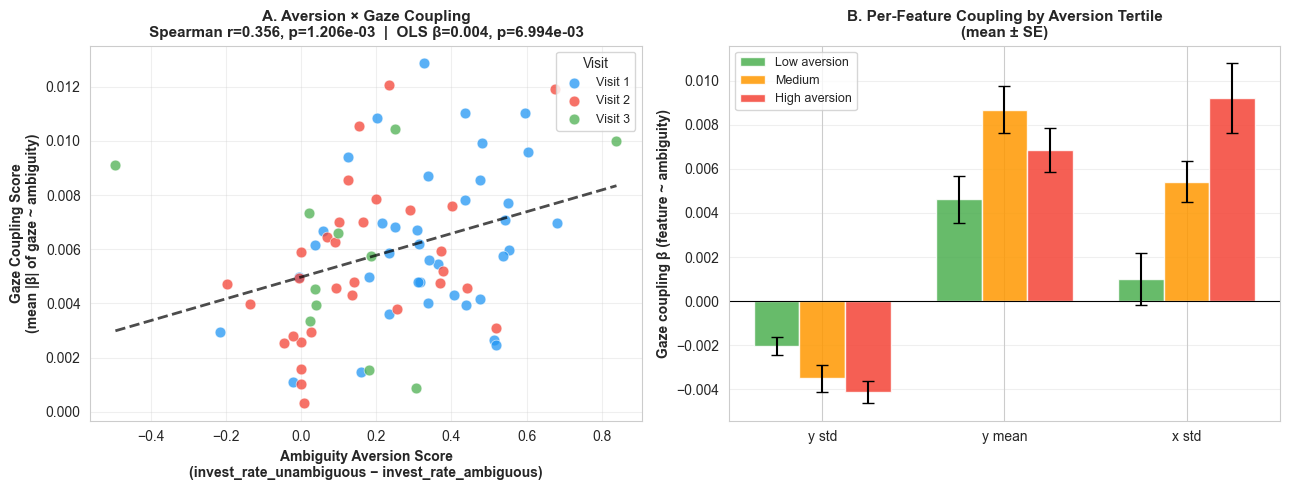

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: scatter with regression line
ax = axes[0]
visit_colors = {1.0: '#2196F3', 2.0: '#F44336', 3.0: '#4CAF50'}
for vis, grp in clean.groupby('visit_number'):
    ax.scatter(grp['aversion'], grp['coupling_score'],
               color=visit_colors.get(vis, 'gray'), label=f'Visit {int(vis)}',
               alpha=0.75, s=60, edgecolors='white', linewidths=0.5)

# Regression line
x_range = np.linspace(clean['aversion'].min(), clean['aversion'].max(), 100)
y_pred   = ols.params['Intercept'] + ols.params['aversion'] * x_range
ax.plot(x_range, y_pred, color='black', linewidth=2, linestyle='--', alpha=0.7)

ax.set_xlabel('Ambiguity Aversion Score\n(invest_rate_unambiguous − invest_rate_ambiguous)',
              fontweight='bold')
ax.set_ylabel('Gaze Coupling Score\n(mean |β| of gaze ~ ambiguity)', fontweight='bold')
ax.set_title(f'A. Aversion × Gaze Coupling\n'
             f'Spearman r={r_sp:.3f}, p={p_sp:.3e}  |  '
             f'OLS β={ols.params["aversion"]:.3f}, p={ols.pvalues["aversion"]:.3e}',
             fontweight='bold', fontsize=11)
ax.legend(title='Visit', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: per-feature betas coloured by aversion quartile
ax = axes[1]
q25, q75 = clean['aversion'].quantile(0.25), clean['aversion'].quantile(0.75)
clean['aversion_group'] = pd.cut(clean['aversion'],
                                  bins=[-np.inf, q25, q75, np.inf],
                                  labels=['Low aversion', 'Medium', 'High aversion'])

feat_cols = [f'beta_{c}' for c in COUPLING_FEATURES if f'beta_{c}' in clean.columns]
feat_labels = [c.replace('gaze_', '').replace('_', ' ') for c in COUPLING_FEATURES]
grp_colors  = {'Low aversion': '#4CAF50', 'Medium': '#FF9800', 'High aversion': '#F44336'}

x_pos = np.arange(len(feat_cols))
width = 0.25
for i, (grp_label, color) in enumerate(grp_colors.items()):
    grp_data = clean[clean['aversion_group'] == grp_label]
    means = [grp_data[fc].mean() for fc in feat_cols]
    sems  = [grp_data[fc].sem()  for fc in feat_cols]
    ax.bar(x_pos + (i - 1) * width, means, width, color=color,
           label=grp_label, alpha=0.85, yerr=sems, capsize=4)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(feat_labels, fontsize=10)
ax.set_ylabel('Gaze coupling β (feature ~ ambiguity)', fontweight='bold')
ax.set_title('B. Per-Feature Coupling by Aversion Tertile\n(mean ± SE)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT / 'aversion_gaze_coupling_crosssectional.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Part B — Visit Trajectory: Δaversion ↔ Δgaze coupling V1→V2

For matched V1/V2 pairs: does the subject-level *change in aversion*
correlate with the *change in gaze coupling*?

If yes → learning decouples the oculomotor system from ambiguity in lockstep
with behavioural de-sensitisation.

In [7]:
sm2 = pd.read_csv('../../data/results/session_mapping.csv',
                  dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm2['subject_id'] = sm2['mmdd'] + '_' + sm2['hhmm'] + '_' + sm2['user_id']

teams_v1 = set(sm2[sm2['visit_number'] == 1.0]['team'])
teams_v2 = set(sm2[sm2['visit_number'] == 2.0]['team'])
v12_teams = sorted(teams_v1 & teams_v2)

def get_sid(team, uid, visit):
    row = sm2[(sm2['team'] == team) & (sm2['user_id'] == uid) & (sm2['visit_number'] == visit)]
    return row['subject_id'].values[0] if len(row) else None

paired_rows = []
for team in v12_teams:
    uids = (set(sm2[(sm2['team'] == team) & (sm2['visit_number'] == 1.0)]['user_id']) &
            set(sm2[(sm2['team'] == team) & (sm2['visit_number'] == 2.0)]['user_id']))
    for uid in uids:
        s1, s2 = get_sid(team, uid, 1.0), get_sid(team, uid, 2.0)
        if s1 is None or s2 is None:
            continue
        r1 = subj_df[subj_df['subject_id'] == s1]
        r2 = subj_df[subj_df['subject_id'] == s2]
        if len(r1) == 0 or len(r2) == 0:
            continue
        d_aversion = r2['aversion'].values[0]       - r1['aversion'].values[0]
        d_coupling = r2['coupling_score'].values[0] - r1['coupling_score'].values[0]
        paired_rows.append({
            'team': team, 'user_id': uid,
            'subj_v1': s1, 'subj_v2': s2,
            'aversion_v1': r1['aversion'].values[0],
            'aversion_v2': r2['aversion'].values[0],
            'coupling_v1': r1['coupling_score'].values[0],
            'coupling_v2': r2['coupling_score'].values[0],
            'delta_aversion': d_aversion,
            'delta_coupling': d_coupling,
        })

paired_df = pd.DataFrame(paired_rows).dropna(subset=['delta_aversion', 'delta_coupling'])
print(f"Matched V1/V2 pairs: {len(paired_df)}")
print(paired_df[['delta_aversion', 'delta_coupling']].describe().round(3))


Matched V1/V2 pairs: 19
       delta_aversion  delta_coupling
count          19.000          19.000
mean           -0.177          -0.001
std             0.199           0.003
min            -0.559          -0.008
25%            -0.280          -0.003
50%            -0.147          -0.001
75%            -0.043           0.001
max             0.096           0.003


In [8]:
# Paired t-tests
t_av, p_av = stats.ttest_1samp(paired_df['delta_aversion'], 0)
t_cp, p_cp = stats.ttest_1samp(paired_df['delta_coupling'], 0)
r_delta, p_delta = stats.spearmanr(paired_df['delta_aversion'], paired_df['delta_coupling'])

print(f"V2 − V1 changes (one-sample t-test vs 0):")
print(f"  Δaversion:        M={paired_df['delta_aversion'].mean():.3f}, t={t_av:.2f}, p={p_av:.3e}")
print(f"  Δcoupling:        M={paired_df['delta_coupling'].mean():.3f}, t={t_cp:.2f}, p={p_cp:.3e}")
print(f"\nCorrelation of Δaversion ↔ Δcoupling:")
print(f"  Spearman r={r_delta:.3f},  p={p_delta:.3e}")

# OLS: delta_coupling ~ delta_aversion
ols_d = smf.ols('delta_coupling ~ delta_aversion', data=paired_df).fit()
print(f"\nOLS Δcoupling ~ Δaversion:")
print(f"  β = {ols_d.params['delta_aversion']:.4f},  p = {ols_d.pvalues['delta_aversion']:.3e}")
print(f"  R² = {ols_d.rsquared:.3f}")


V2 − V1 changes (one-sample t-test vs 0):
  Δaversion:        M=-0.177, t=-3.88, p=1.095e-03
  Δcoupling:        M=-0.001, t=-1.18, p=2.520e-01

Correlation of Δaversion ↔ Δcoupling:
  Spearman r=0.444,  p=5.695e-02

OLS Δcoupling ~ Δaversion:
  β = 0.0056,  p = 1.264e-01
  R² = 0.132


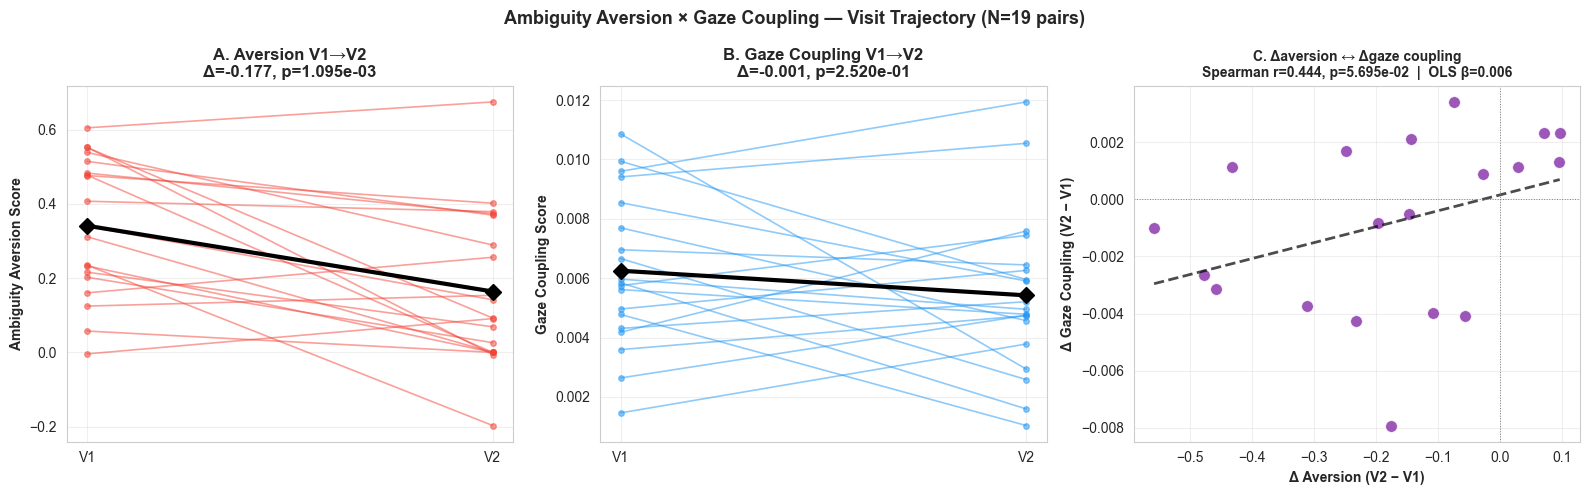

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: V1/V2 aversion
ax = axes[0]
for _, row in paired_df.iterrows():
    ax.plot([1, 2], [row['aversion_v1'], row['aversion_v2']],
            color='#F44336', alpha=0.5, linewidth=1.2, marker='o', markersize=4)
mn_v1, mn_v2 = paired_df['aversion_v1'].mean(), paired_df['aversion_v2'].mean()
ax.plot([1, 2], [mn_v1, mn_v2], color='black', linewidth=3, marker='D', markersize=8, zorder=5)
ax.set_xticks([1, 2]); ax.set_xticklabels(['V1', 'V2'])
ax.set_ylabel('Ambiguity Aversion Score', fontweight='bold')
ax.set_title(f'A. Aversion V1→V2\nΔ={paired_df["delta_aversion"].mean():.3f}, p={p_av:.3e}',
             fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel B: V1/V2 gaze coupling
ax = axes[1]
for _, row in paired_df.iterrows():
    ax.plot([1, 2], [row['coupling_v1'], row['coupling_v2']],
            color='#2196F3', alpha=0.5, linewidth=1.2, marker='o', markersize=4)
mn_v1c, mn_v2c = paired_df['coupling_v1'].mean(), paired_df['coupling_v2'].mean()
ax.plot([1, 2], [mn_v1c, mn_v2c], color='black', linewidth=3, marker='D', markersize=8, zorder=5)
ax.set_xticks([1, 2]); ax.set_xticklabels(['V1', 'V2'])
ax.set_ylabel('Gaze Coupling Score', fontweight='bold')
ax.set_title(f'B. Gaze Coupling V1→V2\nΔ={paired_df["delta_coupling"].mean():.3f}, p={p_cp:.3e}',
             fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel C: Δaversion ↔ Δcoupling scatter
ax = axes[2]
ax.scatter(paired_df['delta_aversion'], paired_df['delta_coupling'],
           color='#7B1FA2', alpha=0.75, s=70, edgecolors='white', linewidths=0.5)
x_range = np.linspace(paired_df['delta_aversion'].min(),
                      paired_df['delta_aversion'].max(), 100)
ax.plot(x_range,
        ols_d.params['Intercept'] + ols_d.params['delta_aversion'] * x_range,
        color='black', linewidth=2, linestyle='--', alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_xlabel('Δ Aversion (V2 − V1)', fontweight='bold')
ax.set_ylabel('Δ Gaze Coupling (V2 − V1)', fontweight='bold')
ax.set_title(f'C. Δaversion ↔ Δgaze coupling\n'
             f'Spearman r={r_delta:.3f}, p={p_delta:.3e}  |  '
             f'OLS β={ols_d.params["delta_aversion"]:.3f}',
             fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Ambiguity Aversion × Gaze Coupling — Visit Trajectory (N={} pairs)'.format(len(paired_df)),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'aversion_gaze_coupling_visit_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Save & Summary

In [10]:
subj_df.to_csv(OUT / 'subject_aversion_coupling_scores.csv', index=False)
paired_df.to_csv(OUT / 'paired_v1v2_aversion_coupling.csv', index=False)

print("=" * 65)
print("SUMMARY: Ambiguity Aversion × Gaze Coupling")
print("=" * 65)

print(f"\nPart A — Cross-sectional (N={len(clean)}):")
print(f"  Spearman r(aversion, coupling) = {r_sp:.3f}, p = {p_sp:.3e}")
if p_sp < 0.05:
    direction = 'POSITIVE' if r_sp > 0 else 'NEGATIVE'
    print(f"  → {direction} correlation: more averse subjects show {'STRONGER' if r_sp>0 else 'WEAKER'} gaze coupling")
else:
    print("  → No significant cross-sectional relationship")

print(f"\nPart B — Visit trajectory (N={len(paired_df)} pairs):")
print(f"  Δaversion V1→V2:  M={paired_df['delta_aversion'].mean():.3f}, p={p_av:.3e}")
print(f"  Δcoupling V1→V2:  M={paired_df['delta_coupling'].mean():.3f}, p={p_cp:.3e}")
print(f"  Δaversion ↔ Δcoupling: r={r_delta:.3f}, p={p_delta:.3e}")
if p_delta < 0.05:
    print("  → Learning-driven changes in aversion and gaze coupling are COUPLED")
else:
    print("  → No significant coupling in visit-to-visit change trajectories")


SUMMARY: Ambiguity Aversion × Gaze Coupling

Part A — Cross-sectional (N=80):
  Spearman r(aversion, coupling) = 0.356, p = 1.206e-03
  → POSITIVE correlation: more averse subjects show STRONGER gaze coupling

Part B — Visit trajectory (N=19 pairs):
  Δaversion V1→V2:  M=-0.177, p=1.095e-03
  Δcoupling V1→V2:  M=-0.001, p=2.520e-01
  Δaversion ↔ Δcoupling: r=0.444, p=5.695e-02
  → No significant coupling in visit-to-visit change trajectories
